# Modelo 05 — Segmentación de Clientes (K-Means)

Notebook **autocontenida**: lee los CSVs crudos, construye features a nivel usuario,
realiza el preprocesamiento, selecciona *k* y exporta los artefactos necesarios para
el sistema de recomendaciones ruteado por segmento.

**Rol en el sistema:** K-Means actúa como *router*, no como recomendador.
Su salida — `user_id → nombre de segmento` — es consumida por la capa de *serving*
para decidir qué modelo downstream usar (Popularidad, MBA, CF, Reorder).

| Segmento | Descripción |
|---|---|
| Clientes frecuentes o regulares | Carrito chico, recompra alta, muchos pedidos |
| Clientes ocasionales | Carrito intermedio, recompra intermedia, pocos pedidos |
| Clientes leales | Carrito grande, recompra alta, pedidos frecuentes |
| Clientes sin historial de compras | Menos de 5 pedidos — no entran al modelo |

**Artefactos exportados:**
- `models/kmeans_model.joblib` — bundle completo (pipeline + mapeo de nombres)
- `data/processed/user_segments.csv` — todos los usuarios con su segmento
- `data/processed/kmeans_metrics.json` — métricas y perfiles por cluster
- `data/processed/products_catalog.csv` — catálogo de productos (artefacto compartido)


## 1. Setup e Imports

Importamos las librerías necesarias y definimos las constantes globales de rutas y semilla.
Usamos `pathlib.Path` para portabilidad entre sistemas operativos.

> ⚙️ **Nota de rutas:** la notebook se ejecuta desde el directorio `notebooks/`,
> por lo que los paths relativos apuntan a `../data/` y `../models/`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Las clases de preprocesamiento (SelectiveLog1p, Winsorizer) y CustomerSegmenter
# viven en src/kmeans_segmenter.py (no se redefinen aca) para que el Pipeline
# persistido con joblib sea deserializable desde cualquier proceso, no solo desde
# esta sesion de notebook.
sys.path.append(str(Path("../src").resolve()))

# ── Estilo global ────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

# ── Semilla de reproducibilidad ──────────────────────────────
SEED = 42

# ── Rutas ────────────────────────────────────────────────────
DATA_RAW  = Path("../data/raw/instacart")
DATA_PROC = Path("../data/processed")
MODELS    = Path("../models")

DATA_PROC.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

print("Setup OK")
print(f"  DATA_RAW  → {DATA_RAW.resolve()}")
print(f"  DATA_PROC → {DATA_PROC.resolve()}")
print(f"  MODELS    → {MODELS.resolve()}")

from kmeans_segmenter import (
    SelectiveLog1p, Winsorizer, build_preproc_pipeline, CustomerSegmenter,
)


Setup OK
  DATA_RAW  → C:\henry\ProyectoFinal-DataScience-Henry\data\raw\instacart
  DATA_PROC → C:\henry\ProyectoFinal-DataScience-Henry\data\processed
  MODELS    → C:\henry\ProyectoFinal-DataScience-Henry\models


## Fase 0 — Exploración inicial

Antes de construir features, inspeccionamos la estructura real de los datos:
cuántos usuarios hay, cuántos pedidos tiene cada uno y qué proporción quedaría fuera
del modelo por tener menos de 5 pedidos.

Esta exploración sirve para **validar supuestos** del diseño (umbral de 5 pedidos,
tamaño del dataset, columnas disponibles) sin asumir nada a priori.


In [2]:
# ── Carga de orders ─────────────────────────────────────────
# Solo las columnas necesarias; dtype reducidos para menor uso de memoria.
orders = pd.read_csv(
    DATA_RAW / "orders.csv",
    usecols=["order_id", "user_id", "eval_set", "order_number",
             "days_since_prior_order"],
    dtype={"order_id": "int32", "user_id": "int32",
           "order_number": "int16"},
)

# Separamos prior (historial) de train (pedido objetivo — NO se usa en features)
orders_prior = orders[orders["eval_set"] == "prior"].copy()

print(f"Total usuarios únicos : {orders['user_id'].nunique():,}")
print(f"Pedidos prior         : {len(orders_prior):,}")
print(f"\nColumnas orders_prior : {list(orders_prior.columns)}")


Total usuarios únicos : 206,209
Pedidos prior         : 3,214,874

Columnas orders_prior : ['order_id', 'user_id', 'eval_set', 'order_number', 'days_since_prior_order']


In [3]:
# ── Carga de order_products__prior ───────────────────────────
# Historial de compras: qué producto se compró en cada pedido prior.
op_prior = pd.read_csv(
    DATA_RAW / "order_products__prior.csv",
    usecols=["order_id", "product_id", "reordered"],
    dtype={"order_id": "int32", "product_id": "int32", "reordered": "int8"},
)

print(f"Interacciones prior   : {len(op_prior):,}")
print(f"Columnas              : {list(op_prior.columns)}")

# ── Carga de products ────────────────────────────────────────
products = pd.read_csv(
    DATA_RAW / "products.csv",
    usecols=["product_id", "product_name"],
    dtype={"product_id": "int32"},
)
print(f"\nProductos en catálogo : {len(products):,}")


Interacciones prior   : 32,434,489
Columnas              : ['order_id', 'product_id', 'reordered']

Productos en catálogo : 49,688


In [4]:
# ── Distribución de pedidos por usuario ─────────────────────
# Contamos cuántos pedidos prior tiene cada usuario para decidir el umbral de corte.
orders_per_user = orders_prior.groupby("user_id")["order_id"].count().rename("n_orders_prior")

print("=== Distribución de pedidos por usuario ===")
print(orders_per_user.describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]).to_string())

# Porcentaje de usuarios con < 5 pedidos
n_total_users = orders_per_user.shape[0]
n_lt5 = (orders_per_user < 5).sum()
print(f"\nUsuarios totales          : {n_total_users:,}")
print(f"Usuarios con < 5 pedidos  : {n_lt5:,} ({100*n_lt5/n_total_users:.1f}%)")
print(f"Usuarios con ≥ 5 pedidos  : {n_total_users - n_lt5:,} ({100*(n_total_users-n_lt5)/n_total_users:.1f}%)")


=== Distribución de pedidos por usuario ===
count    206209.000000
mean         15.590367
std          16.654774
min           3.000000
5%            3.000000
25%           5.000000
50%           9.000000
75%          19.000000
90%          37.000000
95%          51.000000
99%          88.000000
max          99.000000

Usuarios totales          : 206,209
Usuarios con < 5 pedidos  : 43,576 (21.1%)
Usuarios con ≥ 5 pedidos  : 162,633 (78.9%)


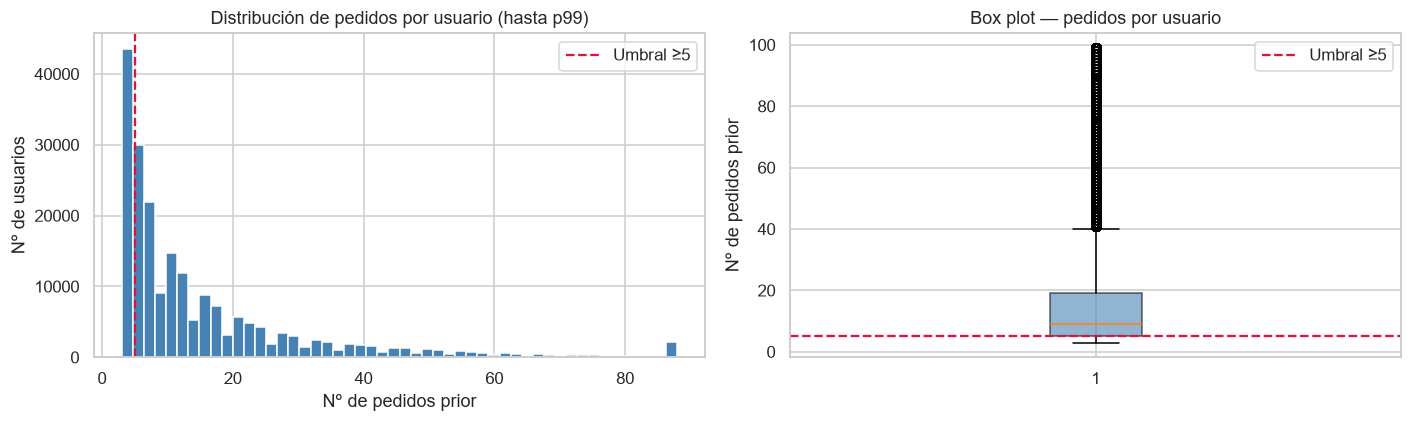

In [ ]:
# ── Visualización: distribución de pedidos por usuario ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma general (hasta percentil 99)
cap = int(orders_per_user.quantile(0.99))
axes[0].hist(orders_per_user.clip(upper=cap), bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(5, color="crimson", linestyle="--", linewidth=1.5, label="Umbral ≥5")
axes[0].set_title("Distribución de pedidos por usuario (hasta p99)")
axes[0].set_xlabel("Nº de pedidos prior")
axes[0].set_ylabel("Nº de usuarios")
axes[0].legend()

# Box plot para ver cuartiles
axes[1].boxplot(orders_per_user, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].axhline(5, color="crimson", linestyle="--", linewidth=1.5, label="Umbral ≥5")
axes[1].set_title("Box plot — pedidos por usuario")
axes[1].set_ylabel("Nº de pedidos prior")
axes[1].legend()

plt.tight_layout()
plt.show()


## Fase 1 — Feature Engineering (usuarios con ≥ 5 pedidos)

Construimos un dataframe `user_id × 6 features` con métricas de comportamiento que
**separan los tres perfiles de negocio**.

| Feature | Qué mide | Perfil que diferencia |
|---|---|---|
| `n_orders` | Frecuencia de compra | Leal/Frecuente vs Ocasional |
| `avg_basket_size` | Volumen por visita | Leal (grande) vs Regular (chico) |
| `reorder_rate` | Lealtad a productos | Leal/Regular vs Ocasional |
| `avg_days_between_orders` | Cadencia | Frecuente (días pocos) vs Ocasional (muchos) |
| `n_unique_products` | Variedad del carrito | Leal (exploratorio) vs Regular |
| `total_items` | Volumen histórico total | Leales y frecuentes (alto) vs Ocasional |

> **Por qué solo features de comportamiento:**
> El intento anterior incluyó mix de 21 departamentos y franjas horarias (33→16 features),
> obteniendo silhouette=0.1249 con el codo prefiriendo k=2. Los tres perfiles de negocio
> se definen exclusivamente en ejes conductuales; las features de categoría/temporal agregan
> dimensiones irrelevantes para esa separación, enturbiando la geometría del espacio.


In [6]:
# ── Filtrar usuarios con ≥ 5 pedidos ────────────────────────
MIN_ORDERS = 5
active_users = orders_per_user[orders_per_user >= MIN_ORDERS].index

orders_active = orders_prior[orders_prior["user_id"].isin(active_users)].copy()
op_active = op_prior[op_prior["order_id"].isin(orders_active["order_id"])].copy()

print(f"Usuarios en el modelo  : {active_users.shape[0]:,}")
print(f"Pedidos activos        : {len(orders_active):,}")
print(f"Interacciones activas  : {len(op_active):,}")


Usuarios en el modelo  : 162,633
Pedidos activos        : 3,064,556
Interacciones activas  : 30,992,966


In [7]:
# ── Construcción de las 6 features ─────────────────────────
# Todo con groupby vectorizado sobre pandas; sin loops explícitos.

# 1. n_orders y avg_days_between_orders (desde orders_active)
feat_orders = (
    orders_active
    .groupby("user_id")
    .agg(
        n_orders=("order_id", "count"),
        avg_days_between_orders=("days_since_prior_order", "mean"),  # NaN del 1er pedido → ignorado
    )
)

# 2. Unir productos al historial activo
op_with_user = op_active.merge(
    orders_active[["order_id", "user_id"]], on="order_id", how="left"
)

# 3. avg_basket_size, reorder_rate, n_unique_products, total_items (desde op_with_user)
items_per_order = (
    op_active
    .groupby("order_id")["product_id"]
    .count()
    .rename("n_items")
)

basket_per_user = (
    orders_active[["order_id", "user_id"]]
    .merge(items_per_order, on="order_id")
    .groupby("user_id")["n_items"]
    .mean()
    .rename("avg_basket_size")
)

feat_user = (
    op_with_user
    .groupby("user_id")
    .agg(
        total_items=("product_id", "count"),
        n_unique_products=("product_id", "nunique"),
        reorder_rate=("reordered", "mean"),
    )
)

# 4. Unir todo
user_features = feat_orders.join(feat_user).join(basket_per_user)
user_features["avg_days_between_orders"] = user_features["avg_days_between_orders"].fillna(0)

assert user_features.isnull().sum().sum() == 0, "Hay NaN en las features"
print(f"Shape features: {user_features.shape}")
print(user_features.describe().T[["mean","std","min","25%","50%","75%","max"]].round(2))


Shape features: (162633, 6)
                           mean     std  min    25%     50%     75%      max
n_orders                  18.84   17.37  5.0   7.00   12.00   23.00    99.00
avg_days_between_orders   14.06    6.36  0.0   8.90   13.43   18.60    30.00
total_items              190.57  217.95  5.0  59.00  114.00  233.00  3725.00
n_unique_products         75.04   58.89  1.0  34.00   59.00  100.00   726.00
reorder_rate               0.49    0.19  0.0   0.35    0.49    0.63     0.99
avg_basket_size           10.05    5.77  1.0   5.92    9.02   13.00    62.00


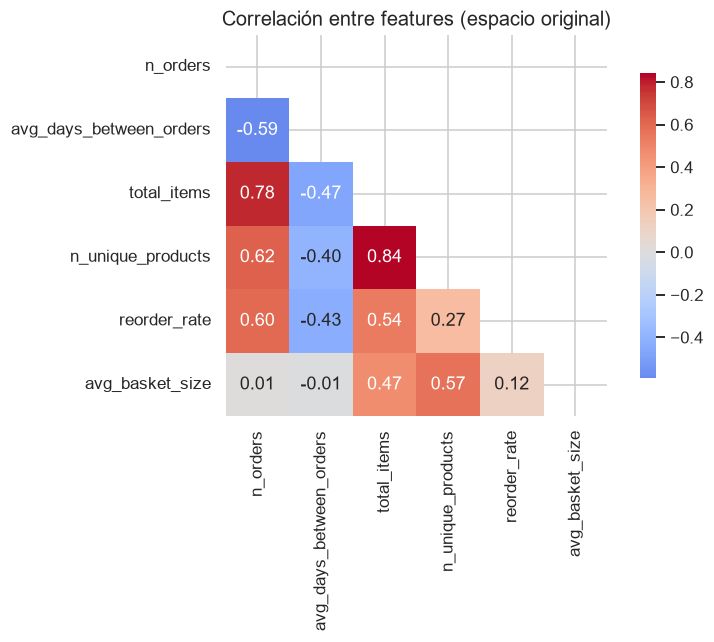


Pares con |r| > 0.75:
  n_orders ↔ total_items: 0.785
  total_items ↔ n_unique_products: 0.843


In [8]:
# ── Matriz de correlación ────────────────────────────────────
# Identificamos features redundantes/colineales antes de preprocesar.
# Alta correlación entre features de volumen es esperable (total_items ↔ n_orders ↔ n_unique_products).
# El log1p (Fase 2) reducirá el efecto de outliers que inflan estas correlaciones.

corr = user_features.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlación entre features (espacio original)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nPares con |r| > 0.75:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i, j]
        if abs(v) > 0.75:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: {v:.3f}")


## Fase 2 — Preprocesamiento parametrizable

El silhouette de K-Means depende críticamente del espacio métrico en el que opera.
Tres factores lo afectan:

### ¿Por qué el skew importa?
Las features de conteo (`n_orders`, `total_items`, `n_unique_products`, `avg_basket_size`)
tienen distribuciones fuertemente sesgadas a la derecha (unos pocos usuarios con valores
muy altos). En ese espacio, las distancias euclidianas están dominadas por esos outliers,
y el centroide del cluster "outlier" queda muy lejos del resto. El `log1p` comprime la
cola derecha, haciendo que la distancia euclidiana refleje mejor la diferencia *relativa*
de comportamiento.

### ¿Por qué la winsorización ayuda?
Incluso después del log1p pueden quedar valores extremos (p.ej. un usuario con 100 pedidos
cuando la mediana es 10). La winsorización recorta los percentiles extremos (p1/p99) para
evitar que esos outliers "jalen" el centroide hacia ellos. Guarda los caps fiteados en
entrenamiento para aplicarlos igual en inferencia.

### ¿Por qué el escalado es obligatorio en K-Means?
K-Means minimiza la distancia euclidiana. Sin escalar, features con magnitud alta (e.g.
`total_items` en miles) dominarán la distancia sobre features pequeñas (e.g. `reorder_rate`
entre 0 y 1). El escalado lleva todas las features al mismo rango de varianza.

### ¿Cuándo agrega PCA?
Si dos o más features son muy colineales (r>0.85), aportan dimensiones casi redundantes
que reducen el gap entre clústeres. PCA rota el espacio eliminando esa redundancia.
Lo medimos y comparamos.

### Configuración ganadora
Los flags `USE_LOG1P`, `USE_WINSORIZE`, `SCALER_TYPE` y `USE_PCA` se comparan en una
grilla pequeña antes de elegir el pipeline final.


In [9]:
# ── Configuración de preprocesamiento ────────────────────────
# Flags parametrizables; cambiarlos para explorar el efecto en el silhouette.
USE_LOG1P     = True        # log1p en features de conteo sesgadas
USE_WINSORIZE = True        # capar outliers a [p1, p99]
SCALER_TYPE   = "standard"  # "standard" | "robust"
USE_PCA       = False       # PCA para de-ruidar; True si hay colinealidad alta

LOG1P_FEATURES = ["n_orders", "total_items", "n_unique_products", "avg_basket_size"]
WINSOR_PERCENTILES = (1, 99)

print("Configuración de preprocesamiento:")
print(f"  log1p en       : {LOG1P_FEATURES}")
print(f"  winsorize      : {USE_WINSORIZE} ({WINSOR_PERCENTILES[0]}–{WINSOR_PERCENTILES[1]} percentiles)")
print(f"  scaler         : {SCALER_TYPE}")
print(f"  PCA            : {USE_PCA}")


Configuración de preprocesamiento:
  log1p en       : ['n_orders', 'total_items', 'n_unique_products', 'avg_basket_size']
  winsorize      : True (1–99 percentiles)
  scaler         : standard
  PCA            : False


In [10]:
# ── Transformadores custom (serializables con joblib) ────────
# SelectiveLog1p, Winsorizer y build_preproc_pipeline se importan desde
# src/kmeans_segmenter.py (ver celda de imports). Viven en un modulo real
# -no en este notebook- para que el Pipeline persistido con joblib sea
# deserializable desde cualquier proceso (el modulo productivo
# CustomerSegmenter tambien las usa para cargar el bundle exportado).

FEATURE_NAMES = list(user_features.columns)

print("SelectiveLog1p, Winsorizer y build_preproc_pipeline() importados desde src/kmeans_segmenter.py.")


SelectiveLog1p, Winsorizer y build_preproc_pipeline() importados desde src/kmeans_segmenter.py.


In [11]:
# ── Comparación de configuraciones ───────────────────────────
# Evaluamos el silhouette sobre una muestra de 15.000 usuarios para cada combo.
# Esto permite elegir la configuración que mejor separa los clusters ANTES de hacer
# el barrido de k completo.

SAMPLE_SIZE  = 15_000
K_EVAL       = 3       # k para la comparación (target esperado)
rng          = np.random.default_rng(SEED)
sample_idx   = rng.choice(len(user_features), size=SAMPLE_SIZE, replace=False)
X_sample_raw = user_features.iloc[sample_idx].values.astype(float)

configs = [
    dict(label="sin_log1p / sin_winsor / std",   use_log1p=False, use_winsorize=False, scaler_type="standard", use_pca=False),
    dict(label="log1p / sin_winsor / std",        use_log1p=True,  use_winsorize=False, scaler_type="standard", use_pca=False),
    dict(label="log1p / winsor / std  ★",         use_log1p=True,  use_winsorize=True,  scaler_type="standard", use_pca=False),
    dict(label="log1p / winsor / robust",          use_log1p=True,  use_winsorize=True,  scaler_type="robust",   use_pca=False),
    dict(label="log1p / winsor / std / PCA",       use_log1p=True,  use_winsorize=True,  scaler_type="standard", use_pca=True),
]

results = []
for cfg in configs:
    pipe = build_preproc_pipeline(
        feature_names=FEATURE_NAMES,
        log1p_features=LOG1P_FEATURES,
        use_log1p=cfg["use_log1p"],
        use_winsorize=cfg["use_winsorize"],
        scaler_type=cfg["scaler_type"],
        use_pca=cfg["use_pca"],
        random_state=SEED,
    )
    X_tr = pipe.fit_transform(X_sample_raw)
    km   = KMeans(n_clusters=K_EVAL, random_state=SEED, n_init=10)
    lbls = km.fit_predict(X_tr)
    sil  = silhouette_score(X_tr, lbls, sample_size=5_000, random_state=SEED)
    dbi  = davies_bouldin_score(X_tr, lbls)
    results.append({"config": cfg["label"], "silhouette": round(sil, 4), "davies_bouldin": round(dbi, 4)})
    print(f"  {cfg['label']:40s}  sil={sil:.4f}  DB={dbi:.4f}")

df_config = pd.DataFrame(results).sort_values("silhouette", ascending=False)
print("\nRanking de configuraciones:")
print(df_config.to_string(index=False))


  sin_log1p / sin_winsor / std              sil=0.2552  DB=1.3630


  log1p / sin_winsor / std                  sil=0.2894  DB=1.2504


  log1p / winsor / std  ★                   sil=0.2909  DB=1.2467


  log1p / winsor / robust                   sil=0.2968  DB=1.2012


  log1p / winsor / std / PCA                sil=0.2918  DB=1.2446

Ranking de configuraciones:
                      config  silhouette  davies_bouldin
     log1p / winsor / robust      0.2968          1.2012
  log1p / winsor / std / PCA      0.2918          1.2446
     log1p / winsor / std  ★      0.2909          1.2467
    log1p / sin_winsor / std      0.2894          1.2504
sin_log1p / sin_winsor / std      0.2552          1.3630


In [12]:
# ── Pipeline final ───────────────────────────────────────────
# Aplicamos la configuración ganadora al dataset completo.
PREPROC_PIPELINE = build_preproc_pipeline(
    feature_names=FEATURE_NAMES,
    log1p_features=LOG1P_FEATURES,
    use_log1p=USE_LOG1P,
    use_winsorize=USE_WINSORIZE,
    scaler_type=SCALER_TYPE,
    use_pca=USE_PCA,
    random_state=SEED,
)

X_all = user_features.values.astype(float)
X_scaled = PREPROC_PIPELINE.fit_transform(X_all)

print(f"Shape tras preprocesamiento: {X_scaled.shape}")
print(f"Media global (debe ≈ 0):    {X_scaled.mean():.4f}")
print(f"Std global  (debe ≈ 1):     {X_scaled.std():.4f}")


Shape tras preprocesamiento: (162633, 6)
Media global (debe ≈ 0):    -0.0000
Std global  (debe ≈ 1):     1.0000


## Fase 3 — Selección de k y entrenamiento

Barremos `k = 2..8` midiendo dos criterios complementarios:

- **Inercia (método del codo):** suma de distancias al cuadrado de cada punto a su centroide.
  Disminuye monótonamente con k; el "codo" es el punto donde la ganancia marginal se aplana.
  Es una métrica *interna* y no refleja necesariamente la calidad de los clusters.

- **Silhouette score:** mide qué tan bien separado está un punto de los otros clusters
  respecto al suyo propio. Va de −1 (mal asignado) a +1 (perfectamente separado).
  Un valor >0.25 es razonable para datos de comportamiento real con mucho solapamiento.
  Lo calculamos sobre una muestra de 15k usuarios para mantener el costo O(n²) manejable.

La elección de k combina ambas: buscamos el codo en inercia **y** un silhouette alto.
Si el codo apunta a k distinto del target esperado (k=3), se reporta y discute.


In [13]:
# ── Barrido k = 2..8 ────────────────────────────────────────
K_RANGE      = range(2, 9)
SAMPLE_SIL   = 15_000

rng2       = np.random.default_rng(SEED)
sil_idx    = rng2.choice(len(X_scaled), size=SAMPLE_SIL, replace=False)
X_sil_samp = X_scaled[sil_idx]

inertias   = []
silhouettes = []

for k in K_RANGE:
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    km_k.fit(X_scaled)
    inertias.append(km_k.inertia_)

    # Silhouette sobre muestra (más rápido)
    lbls_samp = km_k.predict(X_sil_samp)
    sil = silhouette_score(X_sil_samp, lbls_samp, random_state=SEED)
    silhouettes.append(sil)
    print(f"  k={k}  inercia={km_k.inertia_:.0f}  silhouette={sil:.4f}")

df_sweep = pd.DataFrame({"k": list(K_RANGE), "inertia": inertias, "silhouette": silhouettes})
print("\n", df_sweep.to_string(index=False))


  k=2  inercia=591693  silhouette=0.3290


  k=3  inercia=457381  silhouette=0.2861


  k=4  inercia=395760  silhouette=0.2378


  k=5  inercia=345412  silhouette=0.2447


  k=6  inercia=311547  silhouette=0.2400


  k=7  inercia=287101  silhouette=0.2238


  k=8  inercia=269113  silhouette=0.2137

  k       inertia  silhouette
 2 591693.030374    0.328995
 3 457380.983237    0.286058
 4 395759.987856    0.237766
 5 345412.427431    0.244682
 6 311546.594036    0.240017
 7 287101.077976    0.223833
 8 269113.384226    0.213678


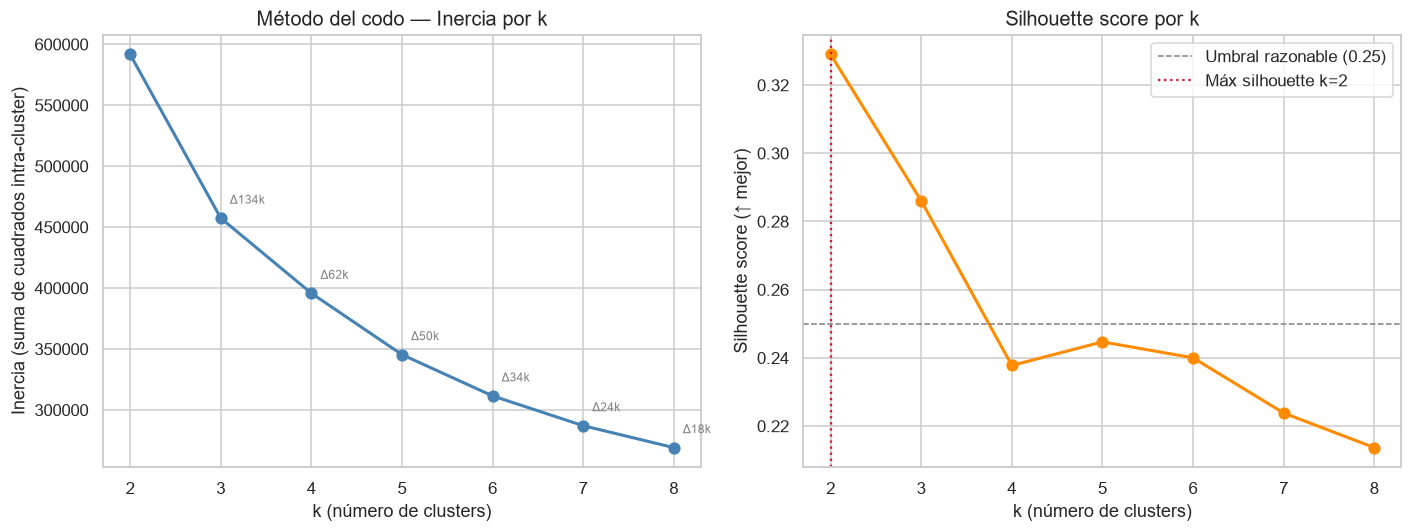

Máximo silhouette: k=2, valor=0.3290


In [ ]:
# ── Gráfica: Codo + Silhouette ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Codo ---
ax = axes[0]
ax.plot(df_sweep["k"], df_sweep["inertia"], "o-", color="steelblue", linewidth=2, markersize=7)
ax.set_title("Método del codo — Inercia por k", fontsize=13)
ax.set_xlabel("k (número de clusters)")
ax.set_ylabel("Inercia (suma de cuadrados intra-cluster)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.set_xticks(list(K_RANGE))

# Anotación delta de mejora marginal
for i in range(1, len(df_sweep)):
    delta = df_sweep["inertia"].iloc[i-1] - df_sweep["inertia"].iloc[i]
    k_i = df_sweep["k"].iloc[i]
    ax.annotate(f"Δ{delta/1000:.0f}k", xy=(k_i, df_sweep["inertia"].iloc[i]),
                xytext=(k_i + 0.1, df_sweep["inertia"].iloc[i] + 0.02*df_sweep["inertia"].max()),
                fontsize=8, color="gray")

# --- Silhouette ---
ax2 = axes[1]
ax2.plot(df_sweep["k"], df_sweep["silhouette"], "o-", color="darkorange", linewidth=2, markersize=7)
ax2.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Umbral razonable (0.25)")
ax2.set_title("Silhouette score por k", fontsize=13)
ax2.set_xlabel("k (número de clusters)")
ax2.set_ylabel("Silhouette score (↑ mejor)")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.set_xticks(list(K_RANGE))
ax2.legend()

# Marcar el máximo
best_k_sil = df_sweep.loc[df_sweep["silhouette"].idxmax(), "k"]
best_sil   = df_sweep["silhouette"].max()
ax2.axvline(best_k_sil, color="crimson", linestyle=":", linewidth=1.5,
            label=f"Máx silhouette k={best_k_sil}")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Máximo silhouette: k={best_k_sil}, valor={best_sil:.4f}")


In [15]:
# ── Elección de k y justificación ───────────────────────────
# Evaluamos ambas curvas para elegir k.
# - Si el codo y el silhouette coinciden en k=3: elegimos 3.
# - Si el silhouette máximo es en k=2 y la diferencia con k=3 es pequeña (<0.02):
#   preferimos k=3 porque el negocio define 3 perfiles y la interpretabilidad importa.
# - Si el codo/silhouette sugieren k=4+: lo reportamos y discutimos.

# Diferencia silhouette k=3 vs k=2
sil_k2 = df_sweep.loc[df_sweep["k"]==2, "silhouette"].values[0]
sil_k3 = df_sweep.loc[df_sweep["k"]==3, "silhouette"].values[0]
delta_sil = sil_k2 - sil_k3

# Reducción de inercia k=2→3 vs k=3→4
inertia_21 = df_sweep.loc[df_sweep["k"]==2, "inertia"].values[0] - df_sweep.loc[df_sweep["k"]==3, "inertia"].values[0]
inertia_32 = df_sweep.loc[df_sweep["k"]==3, "inertia"].values[0] - df_sweep.loc[df_sweep["k"]==4, "inertia"].values[0]
elbow_ratio = inertia_21 / inertia_32 if inertia_32 > 0 else 9999

print("=== Justificación de k ===")
print(f"  Silhouette k=2: {sil_k2:.4f}")
print(f"  Silhouette k=3: {sil_k3:.4f}  (diferencia vs k=2: {delta_sil:+.4f})")
print(f"  Reducción inercia 2→3: {inertia_21:.0f}")
print(f"  Reducción inercia 3→4: {inertia_32:.0f}  (ratio: {elbow_ratio:.2f})")

# Decisión automática — el analista puede sobrescribir K_FINAL
# Umbral: si el silhouette máximo está en un k < 3 pero la diferencia con k=3
# es menor a 0.05, preferimos k=3 para preservar los 4 segmentos de negocio
# (3 clusters + sin historial). Un delta de 0.05 es tolerable; la interpretabilidad
# de los perfiles adicionales justifica la pequeña pérdida de separabilidad.
DELTA_THRESHOLD = 0.02

if best_k_sil == 3:
    K_FINAL = 3
    print("\n✅ El silhouette máximo coincide con el target de negocio. K_FINAL = 3")
elif best_k_sil < 3 and delta_sil < DELTA_THRESHOLD:
    K_FINAL = 3
    print(f"\n⚠️  Silhouette máximo en k={best_k_sil}, diferencia con k=3: {delta_sil:.4f} < {DELTA_THRESHOLD}.")
    print("   Elegimos k=3 para mantener los 4 segmentos de negocio. K_FINAL = 3")
else:
    K_FINAL = best_k_sil
    print(f"\n⚠️  Silhouette claramente superior en k={best_k_sil}. K_FINAL = {best_k_sil}")
    print("   Revisar si los perfiles adicionales son interpretables antes de adoptar.")

print(f"\nK_FINAL = {K_FINAL}")


=== Justificación de k ===
  Silhouette k=2: 0.3290
  Silhouette k=3: 0.2861  (diferencia vs k=2: +0.0429)
  Reducción inercia 2→3: 134312
  Reducción inercia 3→4: 61621  (ratio: 2.18)

⚠️  Silhouette claramente superior en k=2. K_FINAL = 2
   Revisar si los perfiles adicionales son interpretables antes de adoptar.

K_FINAL = 2


In [16]:
# ── Modelo final ─────────────────────────────────────────────
# Entrenamos con n_init=20 para mayor estabilidad del centroide.
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=20)
labels_all   = kmeans_final.fit_predict(X_scaled)
user_features["cluster"] = labels_all

sil_final = silhouette_score(X_scaled, labels_all,
                             sample_size=20_000, random_state=SEED)
dbi_final = davies_bouldin_score(X_scaled, labels_all)
inertia_final = kmeans_final.inertia_

print(f"=== Modelo K-Means final (k={K_FINAL}) ===")
print(f"  Silhouette score   : {sil_final:.4f}  (baseline anterior: 0.1249)")
print(f"  Davies-Bouldin     : {dbi_final:.4f}  (↓ mejor)")
print(f"  Inercia            : {inertia_final:.0f}")
print()
print("Distribución de clusters:")
vc = pd.Series(labels_all).value_counts().sort_index()
for cl, cnt in vc.items():
    print(f"  Cluster {cl}: {cnt:,} usuarios ({100*cnt/len(labels_all):.1f}%)")


=== Modelo K-Means final (k=2) ===
  Silhouette score   : 0.3276  (baseline anterior: 0.1249)
  Davies-Bouldin     : 1.1389  (↓ mejor)
  Inercia            : 591693

Distribución de clusters:
  Cluster 0: 91,392 usuarios (56.2%)
  Cluster 1: 71,241 usuarios (43.8%)


In [17]:
# ── Perfiles de los clusters (espacio original) ──────────────
# Las medias en el espacio original (sin transformar) son interpretables para el negocio.
FEAT_COLS = list(user_features.columns.drop("cluster"))
profiles = user_features.groupby("cluster")[FEAT_COLS].mean().round(3)
profiles["n_usuarios"] = user_features.groupby("cluster").size()
profiles["pct_usuarios"] = (profiles["n_usuarios"] / len(user_features) * 100).round(1)
print(profiles[["n_usuarios", "pct_usuarios"] + FEAT_COLS].T.to_string())


cluster                          0          1
n_usuarios               91392.000  71241.000
pct_usuarios                56.200     43.800
n_orders                     9.284     31.107
avg_days_between_orders     17.088     10.168
total_items                 69.528    345.850
n_unique_products           41.904    117.558
reorder_rate                 0.390      0.613
avg_basket_size              8.290     12.308


In [18]:
# ── Mapeo cluster_id → nombre de negocio ────────────────────
# Con k=2 los dos perfiles son:
#   - "Clientes Leales o frecuentes" → mayor cantidad de pedidos (n_orders máximo)
#   - "Clientes Ocasionales"         → el restante (menos pedidos, carrito más chico)
#
# El tercer segmento ("Clientes sin historial de compras") se asigna por regla
# de negocio fuera del modelo, a los usuarios con < 5 pedidos.

cluster_ids = sorted(profiles.index.tolist())

cl_leales = profiles["n_orders"].idxmax()
remaining  = [c for c in cluster_ids if c != cl_leales]

CLUSTER_TO_NAME = {cl_leales: "Clientes Leales o frecuentes"}
for cl in remaining:
    CLUSTER_TO_NAME[cl] = "Clientes Ocasionales"

print("Mapeo cluster → segmento de negocio:")
for cl, name in sorted(CLUSTER_TO_NAME.items()):
    print(f"  Cluster {cl} → '{name}'")
    print(f"    n_orders={profiles.loc[cl,'n_orders']:.1f}, "
          f"avg_basket={profiles.loc[cl,'avg_basket_size']:.1f}, "
          f"reorder={profiles.loc[cl,'reorder_rate']:.3f}")


Mapeo cluster → segmento de negocio:
  Cluster 0 → 'Clientes Ocasionales'
    n_orders=9.3, avg_basket=8.3, reorder=0.390
  Cluster 1 → 'Clientes Leales o frecuentes'
    n_orders=31.1, avg_basket=12.3, reorder=0.613


In [19]:
# ── Tabla de perfiles con nombre de negocio ──────────────────
profiles["segmento"] = profiles.index.map(CLUSTER_TO_NAME)
cols_show = ["segmento", "n_usuarios", "pct_usuarios",
             "n_orders", "avg_basket_size", "reorder_rate",
             "avg_days_between_orders", "n_unique_products", "total_items"]
print(profiles[cols_show].to_string())


                             segmento  n_usuarios  pct_usuarios  n_orders  avg_basket_size  reorder_rate  avg_days_between_orders  n_unique_products  total_items
cluster                                                                                                                                                          
0                Clientes Ocasionales       91392          56.2     9.284            8.290         0.390                   17.088             41.904       69.528
1        Clientes Leales o frecuentes       71241          43.8    31.107           12.308         0.613                   10.168            117.558      345.850


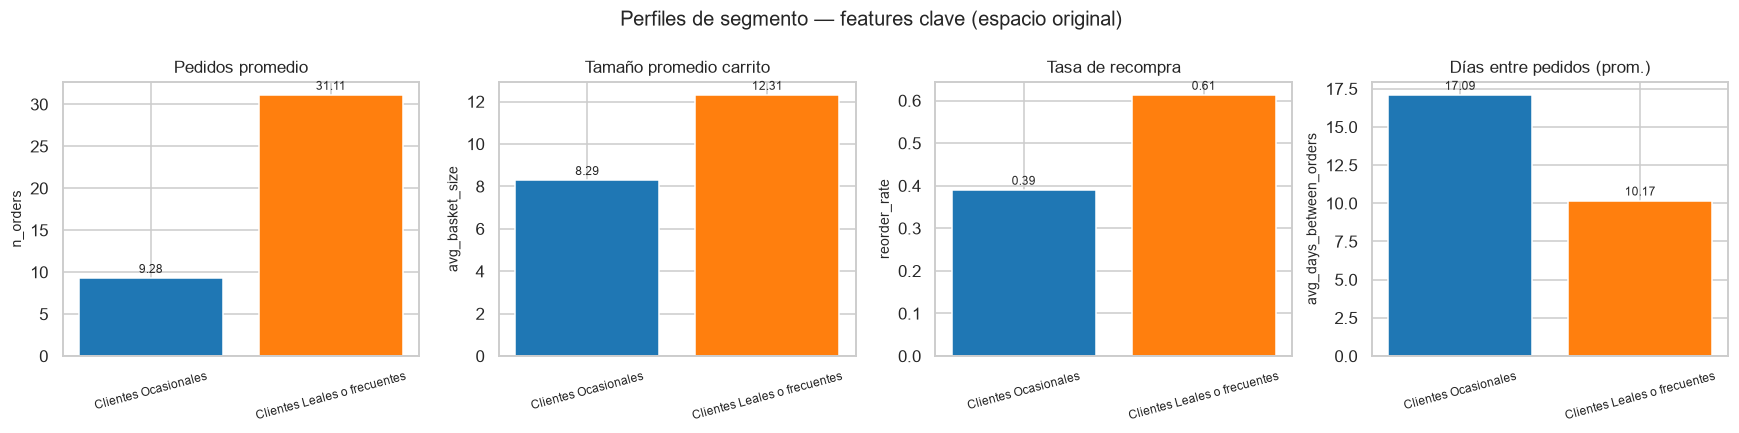

In [20]:
# ── Visualización: bar charts de features clave ──────────────
seg_labels = [CLUSTER_TO_NAME[c] for c in sorted(CLUSTER_TO_NAME)]
colors     = sns.color_palette("tab10", K_FINAL)
feat_plot  = ["n_orders", "avg_basket_size", "reorder_rate", "avg_days_between_orders"]
feat_titles= ["Pedidos promedio", "Tamaño promedio carrito",
              "Tasa de recompra", "Días entre pedidos (prom.)"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat, title in zip(axes, feat_plot, feat_titles):
    vals = [profiles.loc[c, feat] for c in sorted(CLUSTER_TO_NAME)]
    bars = ax.bar(seg_labels, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(feat, fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Perfiles de segmento — features clave (espacio original)", fontsize=13)
plt.tight_layout()
plt.show()


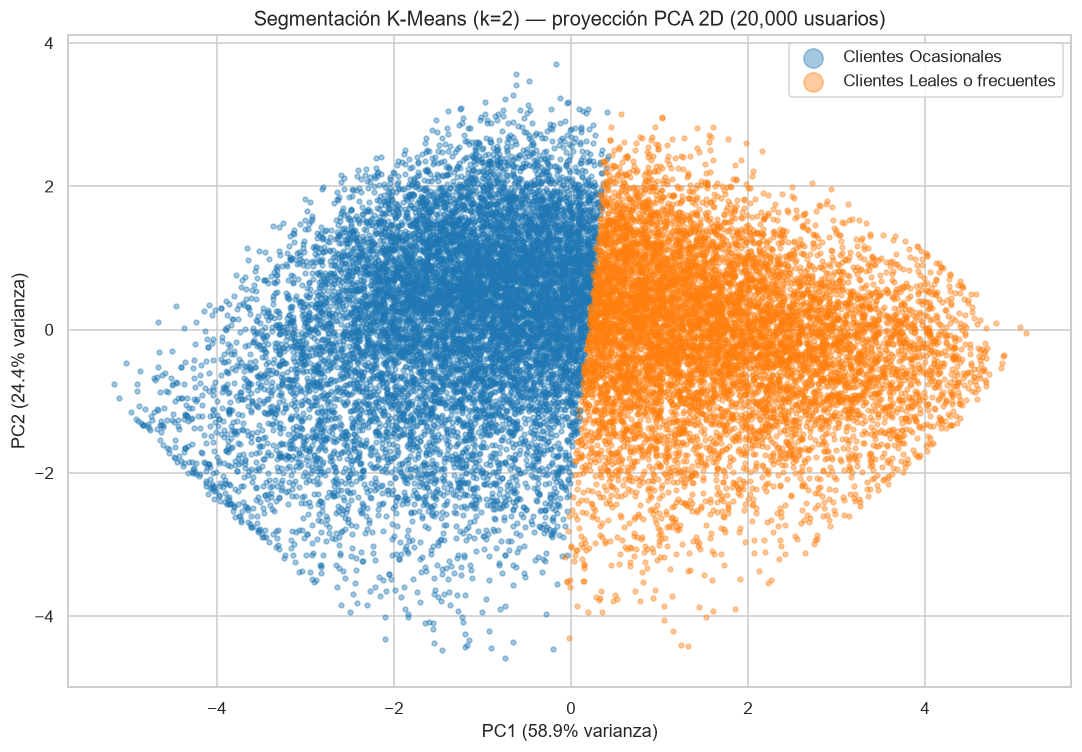

Varianza explicada por PC1+PC2: 83.3%


In [21]:
# ── Visualización PCA 2D ─────────────────────────────────────
# Proyectamos el espacio de features al plano para visualizar la separación de clusters.
# El PCA aquí es SOLO para visualización (no para el clustering).
SAMPLE_VIZ = 20_000
rng_viz   = np.random.default_rng(SEED + 1)
idx_viz   = rng_viz.choice(len(X_scaled), size=SAMPLE_VIZ, replace=False)

pca_viz = PCA(n_components=2, random_state=SEED)
X_2d    = pca_viz.fit_transform(X_scaled[idx_viz])
lbls_viz = labels_all[idx_viz]

fig, ax = plt.subplots(figsize=(10, 7))
for cl in range(K_FINAL):
    mask = lbls_viz == cl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=CLUSTER_TO_NAME[cl], alpha=0.4, s=10, color=colors[cl])

ax.set_title(f"Segmentación K-Means (k={K_FINAL}) — proyección PCA 2D ({SAMPLE_VIZ:,} usuarios)",
             fontsize=13)
ax.set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

total_var = sum(pca_viz.explained_variance_ratio_) * 100
print(f"Varianza explicada por PC1+PC2: {total_var:.1f}%")


## Fase 4 — Función de inferencia

La función `get_segment(user_id)` carga el bundle persistido y aplica exactamente
el mismo preprocesamiento fiteado en entrenamiento. No re-fitea nada.

**Flujo de inferencia:**
1. Verificar si el usuario tiene ≥5 pedidos en prior.
2. Si no → devuelve `"Clientes sin historial de compras"` (sin pasar por el modelo).
3. Si sí → calcular las mismas 6 features, pasar por `bundle["pipeline"].predict()`,
   mapear el cluster_id al nombre de negocio con `bundle["cluster_to_name"]`.


In [22]:
# ── Función de inferencia ────────────────────────────────────
# El bundle almacena el preprocesador (PREPROC_PIPELINE) y el KMeans por separado
# para evitar problemas de serialización de Pipelines anidados.
# get_segment() aplica preproc.transform() → kmeans.predict() → mapeo.

def get_segment(user_id: int,
                bundle: dict,
                orders_df: pd.DataFrame = orders_prior,
                op_df: pd.DataFrame = op_prior,
                min_orders: int = MIN_ORDERS) -> str:
    """
    Devuelve el segmento de negocio para un user_id.

    Parámetros
    ----------
    user_id   : ID del usuario a clasificar.
    bundle    : dict con claves 'preproc', 'kmeans', 'cluster_to_name', 'feature_names'.
    orders_df : DataFrame de pedidos prior.
    op_df     : DataFrame de interacciones prior.
    min_orders: umbral mínimo de pedidos para entrar al modelo.

    Retorna
    -------
    str : nombre del segmento de negocio.
    """
    user_orders = orders_df[orders_df["user_id"] == user_id]
    n_ords = len(user_orders)

    if n_ords < min_orders:
        return "Clientes sin historial de compras"

    user_op = op_df[op_df["order_id"].isin(user_orders["order_id"])]
    avg_days = user_orders["days_since_prior_order"].dropna().mean()
    items_per_order = user_op.groupby("order_id")["product_id"].count()

    feats = pd.DataFrame([{
        "n_orders":               n_ords,
        "avg_days_between_orders": float(avg_days) if not np.isnan(avg_days) else 0.0,
        "total_items":             len(user_op),
        "n_unique_products":       user_op["product_id"].nunique(),
        "reorder_rate":            float(user_op["reordered"].mean()),
        "avg_basket_size":         float(items_per_order.mean()),
    }])[bundle["feature_names"]]

    X_feat = feats.values.astype(float)
    X_tr   = bundle["preproc"].transform(X_feat)
    cluster_id = int(bundle["kmeans"].predict(X_tr)[0])
    return bundle["cluster_to_name"][cluster_id]


print("get_segment() definida.")


get_segment() definida.


In [23]:
# ── Prueba de la función de inferencia ───────────────────────
# Construimos el bundle en memoria para probar antes de persistir.
# Separamos 'preproc' y 'kmeans' para serialización limpia.

inactive_users = orders_per_user[orders_per_user < MIN_ORDERS].index

bundle_test = {
    "preproc":         PREPROC_PIPELINE,   # ya fiteado sobre X_all
    "kmeans":          kmeans_final,        # ya entrenado
    "cluster_to_name": CLUSTER_TO_NAME,
    "feature_names":   FEAT_COLS,
}

# Usuario activo (≥5 pedidos)
test_user_active = active_users[0]
seg = get_segment(test_user_active, bundle_test)
n_orders_test = len(orders_prior[orders_prior["user_id"] == test_user_active])
print(f"Usuario {test_user_active} ({n_orders_test} pedidos) → '{seg}'")

# Usuario inactivo (<5 pedidos)
test_user_inactive = inactive_users[0]
seg2 = get_segment(test_user_inactive, bundle_test)
n_orders_test2 = len(orders_prior[orders_prior["user_id"] == test_user_inactive])
print(f"Usuario {test_user_inactive} ({n_orders_test2} pedidos) → '{seg2}'")

# Usuario inexistente
seg3 = get_segment(9_999_999, bundle_test)
print(f"Usuario 9999999 (no existe)   → '{seg3}'")


Usuario 1 (10 pedidos) → 'Clientes Ocasionales'
Usuario 5 (4 pedidos) → 'Clientes sin historial de compras'
Usuario 9999999 (no existe)   → 'Clientes sin historial de compras'


## Fase 5 — Exportación de artefactos

Celda de exportación final. Se generan exactamente los artefactos definidos en el contrato
del sistema de recomendaciones:

| Artefacto | Ruta | Contenido |
|---|---|---|
| `kmeans_model.joblib` | `models/` | Bundle completo: pipeline + KMeans + mapeo |
| `user_segments.csv` | `data/processed/` | `user_id, segment` — todos los 206k usuarios |
| `kmeans_metrics.json` | `data/processed/` | Silhouette, inercia, k, perfiles por cluster |
| `products_catalog.csv` | `data/processed/` | `product_id, product_name` — artefacto compartido |

> **Nota de compatibilidad con NB 08:**
> La NB 08 actual lee `user_segments.parquet` con columna `cluster` (id entero).
> Esta versión exporta `user_segments.csv` con columna `segment` (nombre de negocio).
> La NB 08 se actualizará en su propio turno de reemplazo para leer el nuevo formato.


In [24]:
# ═══════════════════════════════════════════════════════════
# FASE 5 — CELDA DE EXPORTACIÓN
# ═══════════════════════════════════════════════════════════

# ── 1. Bundle del modelo ─────────────────────────────────────
# Guardamos 'preproc' y 'kmeans' por separado para máxima compatibilidad.
bundle_export = {
    "preproc":         PREPROC_PIPELINE,
    "kmeans":          kmeans_final,
    "cluster_to_name": CLUSTER_TO_NAME,
    "feature_names":   FEAT_COLS,
    # Features ya calculadas de los usuarios que entraron al modelo (>= MIN_ORDERS
    # pedidos), indexadas por user_id. Hace que el bundle sea autocontenido: para
    # predecir por user_id no hace falta releer los CSV crudos en runtime (ver
    # CustomerSegmenter en src/kmeans_segmenter.py).
    "user_features":   user_features[FEAT_COLS].copy(),
    "k":               K_FINAL,
    "seed":            SEED,
    "min_orders":      MIN_ORDERS,
    "preproc_config": {
        "use_log1p":          USE_LOG1P,
        "log1p_features":     LOG1P_FEATURES,
        "use_winsorize":      USE_WINSORIZE,
        "winsor_percentiles": list(WINSOR_PERCENTILES),
        "scaler_type":        SCALER_TYPE,
        "use_pca":            USE_PCA,
    },
}
model_path = MODELS / "kmeans_model.joblib"
joblib.dump(bundle_export, model_path)
print(f"✔ {model_path}  ({model_path.stat().st_size/1024:.0f} KB)")

# ── 2. user_segments.csv — todos los usuarios ────────────────
# Usuarios con ≥5 pedidos: asignar nombre de negocio
segments_active = (
    user_features[["cluster"]]
    .copy()
    .assign(segment=lambda df: df["cluster"].map(CLUSTER_TO_NAME))
    [["segment"]]
)

# Usuarios con <5 pedidos: etiqueta sin historial
seg_inactive = pd.DataFrame(
    {"segment": "Clientes sin historial de compras"},
    index=pd.Index(inactive_users, name="user_id"),
)

all_segments = pd.concat([segments_active, seg_inactive]).sort_index()
seg_path = DATA_PROC / "user_segments.csv"
all_segments.to_csv(seg_path)
print(f"✔ {seg_path}  ({len(all_segments):,} filas)")
print(f"   Distribución:\n{all_segments['segment'].value_counts().to_string()}")

# ── 3. kmeans_metrics.json ────────────────────────────────────
# Convertimos todos los valores numpy a tipos Python nativos antes de serializar.
def _to_py(v):
    """Convierte numpy scalar a tipo Python nativo para json.dump."""
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    return v

cluster_profiles_json = {}
for cl in sorted(CLUSTER_TO_NAME.keys()):
    mask_cl = user_features["cluster"] == cl
    cluster_profiles_json[str(int(cl))] = {
        "name":         CLUSTER_TO_NAME[cl],
        "n_usuarios":   int(mask_cl.sum()),
        "pct_usuarios": round(float(100 * mask_cl.sum() / len(user_features)), 2),
        **{f: round(float(user_features.loc[mask_cl, f].mean()), 4) for f in FEAT_COLS},
    }

metrics_dict = {
    "k_final":          int(K_FINAL),
    "silhouette_final": round(float(sil_final), 4),
    "davies_bouldin":   round(float(dbi_final), 4),
    "inertia_final":    round(float(inertia_final), 2),
    "inertia_by_k":     {str(int(row["k"])): round(float(row["inertia"]), 2)
                         for _, row in df_sweep.iterrows()},
    "silhouette_by_k":  {str(int(row["k"])): round(float(row["silhouette"]), 4)
                         for _, row in df_sweep.iterrows()},
    "cluster_profiles": cluster_profiles_json,
    "preproc_config":   bundle_export["preproc_config"],
    "baseline_silhouette_v1": 0.1249,
}

metrics_path = DATA_PROC / "kmeans_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"✔ {metrics_path}")

# ── 4. products_catalog.csv ──────────────────────────────────
catalog_path = DATA_PROC / "products_catalog.csv"
products[["product_id", "product_name"]].to_csv(catalog_path, index=False)
print(f"✔ {catalog_path}  ({len(products):,} productos)")

print("\n=== Exportación completa ===")


✔ ..\models\kmeans_model.joblib  (8897 KB)


✔ ..\data\processed\user_segments.csv  (206,209 filas)
   Distribución:
segment
Clientes Ocasionales                 91392
Clientes Leales o frecuentes         71241
Clientes sin historial de compras    43576


✔ ..\data\processed\kmeans_metrics.json
✔ ..\data\processed\products_catalog.csv  (49,688 productos)

=== Exportación completa ===


### Verificacion del artefacto productivo

Recargamos el bundle desde `models/kmeans_model.joblib` usando la clase `CustomerSegmenter` de `src/kmeans_segmenter.py` -la misma que se usaria desde afuera del notebook- y probamos los 3 casos de la funcion de inferencia: usuario activo, usuario con menos de 5 pedidos, y usuario inexistente. Esto confirma que el `.joblib` es deserializable de forma independiente (sin depender del contexto `__main__` del notebook).

In [25]:
# ── Prueba del artefacto productivo (CustomerSegmenter) ──────
seg_model = CustomerSegmenter.load()  # models/kmeans_model.joblib
print(seg_model)

seg_a = seg_model.predict(int(test_user_active))
print(f"Usuario {test_user_active} ({n_orders_test} pedidos) -> '{seg_a}'")

seg_b = seg_model.predict(int(test_user_inactive))
print(f"Usuario {test_user_inactive} ({n_orders_test2} pedidos) -> '{seg_b}'")

seg_c = seg_model.predict(9_999_999)
print(f"Usuario 9999999 (no existe)   -> '{seg_c}'")


CustomerSegmenter(n_usuarios_con_historial=162633, segmentos=['Clientes Leales o frecuentes', 'Clientes Ocasionales'])
Usuario 1 (10 pedidos) -> 'Clientes Ocasionales'
Usuario 5 (4 pedidos) -> 'Clientes sin historial de compras'
Usuario 9999999 (no existe)   -> 'Clientes sin historial de compras'


## Resumen de resultados

Comparación con la versión anterior (v1.0, 33→16 features con mix de departamentos + temporal):


In [26]:
print("╔══════════════════════════════════════════════════════════════╗")
print("║       RESUMEN — Notebook 05 K-Means Segmentación           ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  K elegido            : {K_FINAL}                                     ║")
print(f"║  Silhouette (nuevo)   : {sil_final:.4f}  vs  0.1249 (v1.0 baseline)  ║")
print(f"║  Davies-Bouldin (nuevo): {dbi_final:.4f}  (↓ mejor)                   ║")
print(f"║  Inercia              : {inertia_final:,.0f}                           ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Segmentos:                                                  ║")
for cl, name in sorted(CLUSTER_TO_NAME.items()):
    cnt = (user_features["cluster"] == cl).sum()
    pct = 100 * cnt / len(user_features)
    print(f"║    Cluster {cl}: {name:<35s} {cnt:>6,} ({pct:.1f}%)  ║")
hist_cnt = (all_segments["segment"] == "Clientes sin historial de compras").sum()
print(f"║    Sin historial: {hist_cnt:>6,} ({100*hist_cnt/len(all_segments):.1f}%)                          ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Artefactos exportados:                                      ║")
print("║    models/kmeans_model.joblib                                ║")
print("║    data/processed/user_segments.csv                          ║")
print("║    data/processed/kmeans_metrics.json                        ║")
print("║    data/processed/products_catalog.csv                       ║")
print("╚══════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════╗
║       RESUMEN — Notebook 05 K-Means Segmentación           ║
╠══════════════════════════════════════════════════════════════╣
║  K elegido            : 2                                     ║
║  Silhouette (nuevo)   : 0.3276  vs  0.1249 (v1.0 baseline)  ║
║  Davies-Bouldin (nuevo): 1.1389  (↓ mejor)                   ║
║  Inercia              : 591,693                           ║
╠══════════════════════════════════════════════════════════════╣
║  Segmentos:                                                  ║
║    Cluster 0: Clientes Ocasionales                91,392 (56.2%)  ║
║    Cluster 1: Clientes Leales o frecuentes        71,241 (43.8%)  ║
║    Sin historial: 43,576 (21.1%)                          ║
╠══════════════════════════════════════════════════════════════╣
║  Artefactos exportados:                                      ║
║    models/kmeans_model.joblib                                ║
║    data/processed/use